<a href="https://colab.research.google.com/github/pramodgurung10/AI-ML/blob/main/Worksheet4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [12]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [13]:
import zipfile
import os

zip_file_path = '/content/drive/MyDrive/ConceptAI/Copy of devnagari digit.zip'
data_path = '/content/drive/MyDrive/ConceptAI'
destination_directory = os.path.dirname(data_path)

with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall(destination_directory)

print(f"Successfully unzipped '{zip_file_path}' to '{destination_directory}'")

Successfully unzipped '/content/drive/MyDrive/ConceptAI/Copy of devnagari digit.zip' to '/content/drive/MyDrive'


In [14]:
pip install keras tensorflow

In [15]:
import tensorflow as tf
print(tf.keras.__version__)

3.13.2


Manual Gradient Calculation in **Numpy**

In [16]:
import numpy as np
# Simple function f(x) = x^2
def f(x):
  return x ** 2
# Manual derivative (f’(x) = 2x)
def gradient(x):
  return 2 * x
# Update rule: x = x - learning_rate * gradient
x = 5.0
learning_rate = 0.1
for _ in range(10): # Manually optimize for 10 steps
  x -= learning_rate * gradient(x)
  print(f"x: {x}, f(x): {f(x)}")

x: 4.0, f(x): 16.0
x: 3.2, f(x): 10.240000000000002
x: 2.56, f(x): 6.5536
x: 2.048, f(x): 4.194304
x: 1.6384, f(x): 2.68435456
x: 1.31072, f(x): 1.7179869184000003
x: 1.0485760000000002, f(x): 1.0995116277760004
x: 0.8388608000000002, f(x): 0.7036874417766403
x: 0.6710886400000001, f(x): 0.45035996273704976
x: 0.5368709120000001, f(x): 0.2882303761517119


**Gradient Computations with Keras.**

In [17]:
import tensorflow as tf
x = tf.Variable(5.0) # Trainable variable
with tf.GradientTape() as tape:
  y = x ** 2 # y = x^2
grad = tape.gradient(y, x) # Computes dy/dx automatically
print(grad.numpy()) # Output: 10.0

10.0


**Example: Matrix Multiplication Speed (Numpy vs. Tensorflow on GPU).**

In [18]:
import numpy as np
import tensorflow as tf
import time
# Create large random matrices
size = (1000, 1000)
A = np.random.rand(*size)
B = np.random.rand(*size)
# NumPy Multiplication
start = time.time()
C_numpy = np.dot(A, B)
print("NumPy Time:", time.time() - start)
# TensorFlow Multiplication (for colab uses GPU Runtime if available)
A_tf = tf.constant(A)
B_tf = tf.constant(B)
start = time.time()
C_tf = tf.matmul(A_tf, B_tf)
print("TensorFlow Time:", time.time() - start)

NumPy Time: 0.12546777725219727
TensorFlow Time: 0.24706029891967773


**Implementation of Activation Function with Keras.**

In [19]:
from tensorflow.keras.layers import Dense
layer = Dense(64, activation='sigmoid')

**Manually Training Network in Numpy.**

In [20]:
import numpy as np

# Placeholder data for demonstration
x_train = np.array([[1.0], [2.0], [3.0], [4.0]])
y_train = np.array([[2.0], [4.0], [6.0], [8.0]])
weights = np.array([[0.0]]) # Initialize weights
learning_rate = 0.01 # Define learning rate

for epoch in range(10):
  # Forward pass
  y_pred = np.dot(x_train, weights)
  # Compute loss
  loss = np.mean((y_pred - y_train) ** 2)
  # Compute gradients manually
  gradients = 2 * np.dot(x_train.T, (y_pred - y_train)) / len(x_train)
  # Update weights
  weights -= learning_rate * gradients
  print(f"Epoch {epoch+1}, Loss: {loss:.4f}, Weights: {weights[0][0]:.4f}")

Epoch 1, Loss: 30.0000, Weights: 0.3000
Epoch 2, Loss: 21.6750, Weights: 0.5550
Epoch 3, Loss: 15.6602, Weights: 0.7717
Epoch 4, Loss: 11.3145, Weights: 0.9560
Epoch 5, Loss: 8.1747, Weights: 1.1126
Epoch 6, Loss: 5.9062, Weights: 1.2457
Epoch 7, Loss: 4.2673, Weights: 1.3588
Epoch 8, Loss: 3.0831, Weights: 1.4550
Epoch 9, Loss: 2.2275, Weights: 1.5368
Epoch 10, Loss: 1.6094, Weights: 1.6063


In [21]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# Define a simple Keras model
model = Sequential([
    Dense(1, input_shape=(1,))
])

# Compile the model (using SGD optimizer and MSE loss to mimic the numpy example)
model.compile(optimizer='sgd', loss='mse')

# Now, fit the model
model.fit(x_train, y_train, epochs=10, batch_size=32)

Epoch 1/10


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 211ms/step - loss: 87.1719
Epoch 2/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - loss: 60.5409
Epoch 3/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - loss: 42.0619
Epoch 4/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - loss: 29.2393
Epoch 5/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - loss: 20.3417
Epoch 6/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - loss: 14.1676
Epoch 7/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - loss: 9.8831
Epoch 8/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - loss: 6.9099
Epoch 9/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - loss: 4.8466
Epoch 10/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - loss: 3.4145


In [22]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
model = Sequential([
  Dense(64, activation='relu', input_shape=(784,)),
  Dense(10, activation='softmax')
])

In [23]:
learning_rate = 0.01
weights = np.random.randn(3, 3)
for _ in range(100): # Training loop
  gradient = np.random.randn(3, 3) # Fake gradient for illustration
  weights -= learning_rate * gradient

In [24]:
from tensorflow.keras.optimizers import SGD
optimizer = SGD(learning_rate=0.01)

In [25]:
from tensorflow.keras.layers import Dense
units = 64 # Define the number of units/neurons for the layer
layer = Dense(units, activation=None, use_bias=True, kernel_initializer="glorot_uniform")

In [26]:
from tensorflow.keras.layers import Dense
layer = Dense(64, activation="sigmoid") # 64 neurons with sigmoid activation

**Building a Simple Fully Connected Neural Network in Keras.**

1. Load and Preprocess the Data:

Training set: (17000, 28, 28, 1), Labels: (17000, 10)
Testing set: (3000, 28, 28, 1), Labels: (3000, 10)


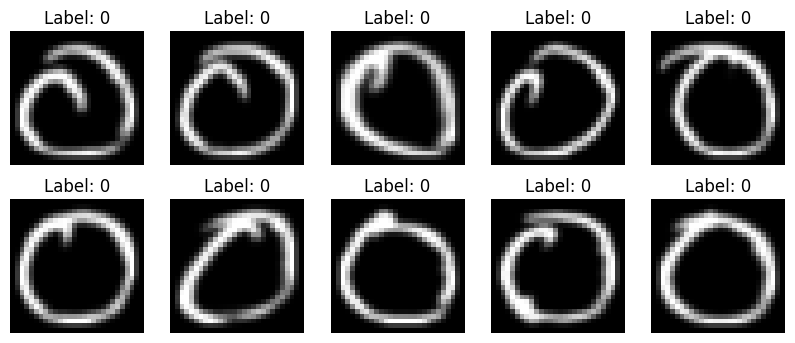

In [27]:
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from PIL import Image # Import Pillow

# Define dataset paths
train_dir = "/content/drive/MyDrive/DevanagariHandwrittenDigitDataset/Train"
test_dir = "/content/drive/MyDrive/DevanagariHandwrittenDigitDataset/Test"

# Define image size
img_height, img_width = 28, 28

# Function to load images and labels using PIL
def load_images_from_folder(folder):
  images = []
  labels = []
  class_names = sorted(os.listdir(folder)) # Sorted class names (digit_0, digit_1, ...)
  class_map = {name: i for i, name in enumerate(class_names)} # Map class names to labels

  for class_name in class_names:
    class_path = os.path.join(folder, class_name)
    label = class_map[class_name]
    for filename in os.listdir(class_path):
      img_path = os.path.join(class_path, filename)
      try:
        # Load image using PIL
        img = Image.open(img_path).convert("L") # Convert to grayscale
        img = img.resize((img_width, img_height)) # Resize to (28,28)
        img = np.array(img) / 255.0 # Normalize pixel values to [0,1]
        images.append(img)
        labels.append(label)
      except Image.UnidentifiedImageError:
        print(f"Warning: Could not identify image file {img_path}. Skipping.")
      except Exception as e:
        print(f"Warning: Error loading image {img_path}: {e}. Skipping.")

  return np.array(images), np.array(labels)

# Load training and testing datasets
x_train, y_train = load_images_from_folder(train_dir)
x_test, y_test = load_images_from_folder(test_dir)

# Reshape images for Keras input
x_train = x_train.reshape(-1, img_height, img_width, 1) # Shape (num_samples, 28, 28, 1)
x_test = x_test.reshape(-1, img_height, img_width, 1)

# One-hot encode labels
y_train = to_categorical(y_train, num_classes=10)
y_test = to_categorical(y_test, num_classes=10)

# Print dataset shape
print(f"Training set: {x_train.shape}, Labels: {y_train.shape}")
print(f"Testing set: {x_test.shape}, Labels: {y_test.shape}")

# Visualize some images
plt.figure(figsize=(10, 4))
for i in range(10):
  plt.subplot(2, 5, i + 1)
  plt.imshow(x_train[i].reshape(28, 28), cmap='gray')
  plt.title(f"Label: {np.argmax(y_train[i])}")
  plt.axis("off")
plt.show()

Reshaping for Keras compatibility:

In [28]:
x_train = x_train.reshape(-1, img_height, img_width, 1)
# Use with Cautions.

In [29]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import mnist
# Load the MNIST dataset
(x_train, y_train), (x_test, y_test) = mnist.load_data()
# Normalize the images to values between 0 and 1
x_train, x_test = x_train / 255.0, x_test / 255.0
# Flatten the 28x28 images into 784-dimensional vectors
x_train = x_train.reshape(-1, 28 * 28)
x_test = x_test.reshape(-1, 28 * 28)
# One-hot encode the labels (0-9) for classification
y_train = tf.keras.utils.to_categorical(y_train, 10)
y_test = tf.keras.utils.to_categorical(y_test, 10)

#Exercise: Building a Fully Connected Network (FCN) for Devnagari Digit Classification.

Task 1: Data Preparation

Loading the Data

• Download the provided folder that contains the Devnagari digits dataset.

• Use the Python Imaging Library (PIL) to load and read the image files from the dataset.

• Convert the images into Numpy arrays and normalize them to a range of 0-1.

• use train folder for training and test for testing.

• Extract the corresponding labels for each image.

Hints:

• Ensure that the images are resized to a consistent shape (e.g., 28x28).

• Convert labels to one-hot encoded format for multi-class classification.

Training set: (17000, 28, 28, 1), Labels: (17000, 10)
Testing set: (3000, 28, 28, 1), Labels: (3000, 10)


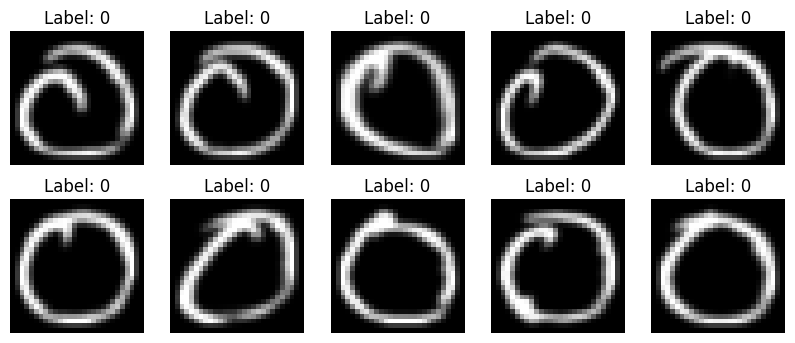

In [30]:
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from PIL import Image # Import Pillow
# Define dataset paths
train_dir ="/content/drive/MyDrive/DevanagariHandwrittenDigitDataset/Train"
test_dir ="/content/drive/MyDrive/DevanagariHandwrittenDigitDataset/Test"
# Define image size
img_height, img_width = 28, 28
# Function to load images and labels using PIL
def load_images_from_folder(folder):
  images = []
  labels = []
  class_names = sorted(os.listdir(folder)) # Sorted class names (digit_0, digit_1, ...)
  class_map = {name: i for i, name in enumerate(class_names)} # Map class names to labels
  for class_name in class_names:
    class_path = os.path.join(folder, class_name)
    label = class_map[class_name]
    for filename in os.listdir(class_path):
      img_path = os.path.join(class_path, filename)
      # Load image using PIL
      img = Image.open(img_path).convert("L") # Convert to grayscale
      img = img.resize((img_width, img_height)) # Resize to (28,28)
      img = np.array(img) / 255.0 # Normalize pixel values to [0,1]
      images.append(img)
      labels.append(label)
  return np.array(images), np.array(labels)
# Load training and testing datasets
x_train, y_train = load_images_from_folder(train_dir)
x_test, y_test = load_images_from_folder(test_dir)
# Reshape images for Keras input
x_train = x_train.reshape(-1, img_height, img_width, 1) # Shape (num_samples, 28, 28, 1)
x_test = x_test.reshape(-1, img_height, img_width, 1)
# One-hot encode labels
y_train = to_categorical(y_train, num_classes=10)
y_test = to_categorical(y_test, num_classes=10)
# Print dataset shape
print(f"Training set: {x_train.shape}, Labels: {y_train.shape}")
print(f"Testing set: {x_test.shape}, Labels: {y_test.shape}")
# Visualize some images
plt.figure(figsize=(10, 4))
for i in range(10):
  plt.subplot(2, 5, i + 1)
  plt.imshow(x_train[i].reshape(28, 28), cmap='gray')
  plt.title(f"Label: {np.argmax(y_train[i])}")
  plt.axis("off")
plt.show()

Task 2: Build the FCN Model
Model Architecture

• Create a Sequential model using Keras.

• Add 3 hidden layers with the following number of neurons:

– 1st hidden layer: 64 neurons

– 2nd hidden layer: 128 neurons

– 3rd hidden layer: 256 neurons

• Use sigmoid activation functions for all hidden layers.

• Add an output layer with 10 units with softmax (since Devnagari digits have 10 classes) and a
softmax activation function.

In [31]:
import tensorflow as tf
from tensorflow import keras
num_classes = 10
input_shape = (28, 28, 1)
model = keras.Sequential(
[
  keras.layers.Input(shape=input_shape),
  keras.layers.Flatten(), # Flatten the 28x28 image to a 784-dimensional vector
  keras.layers.Dense(64, activation="sigmoid"),
  keras.layers.Dense(128, activation="sigmoid"),
  keras.layers.Dense(256, activation="sigmoid"),
  keras.layers.Dense(num_classes, activation="softmax"),
]
)

model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 64)             │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 94,154 (367.79 KB)

 Trainable params: 94,154 (367.79 KB)

 Non-trainable params: 0 (0.00 B)

Task 3: Compile the Model
Model Compilation

• Choose an appropriate optimizer (e.g., Adam), loss function (e.g., sparse categorical crossentropy),
and evaluation metric (e.g., accuracy).

In [32]:
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

Task 4: Train the Model
Model Training

• Use the model.fit() function to train the model. Set the batch size to 128 and the number of
epochs to 20.

• Use validation split (validation split=0.2) to monitor the model’s performance on validation
data.

• Optionally, use callbacks such as ModelCheckpoint and EarlyStopping for saving the best model
and avoiding overfitting.

In [33]:
history = model.fit(x_train, y_train, epochs=20, batch_size=128, validation_split=0.2)

Epoch 1/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - accuracy: 0.4658 - loss: 1.7081 - val_accuracy: 0.0000e+00 - val_loss: 6.5695
Epoch 2/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.8396 - loss: 0.5435 - val_accuracy: 0.0000e+00 - val_loss: 7.8871
Epoch 3/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9201 - loss: 0.2755 - val_accuracy: 0.0000e+00 - val_loss: 8.5859
Epoch 4/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9485 - loss: 0.1820 - val_accuracy: 0.0000e+00 - val_loss: 8.9090
Epoch 5/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9590 - loss: 0.1397 - val_accuracy: 0.0000e+00 - val_loss: 9.2216
Epoch 6/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9681 - loss: 0.1109 - val_accuracy: 0.0000e+00 - val_loss: 9.5160
Epoch 7/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9745 - loss: 0.0918 - val_accuracy: 0.0000e+00 - val_loss: 9.8210
Epoch 8/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9796 - lo

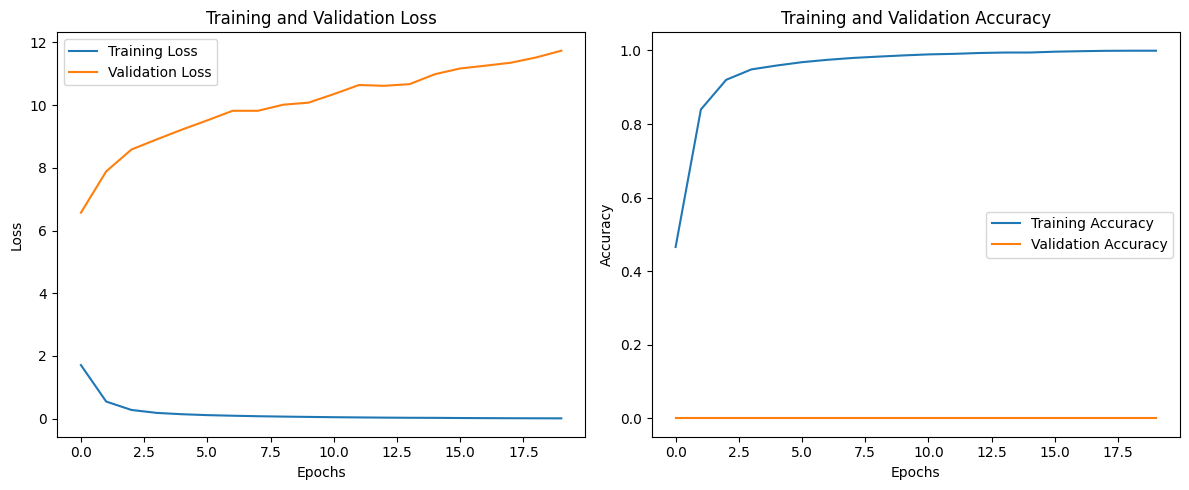

In [34]:
# Visualization: Training and Validation Loss and Accuracy

import matplotlib.pyplot as plt

# Extract values from history
train_loss = history.history['loss']
val_loss = history.history['val_loss']
train_acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

# Plot loss
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(train_loss, label='Training Loss')
plt.plot(val_loss, label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()

# Plot accuracy
plt.subplot(1, 2, 2)
plt.plot(train_acc, label='Training Accuracy')
plt.plot(val_acc, label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

Task 5: Evaluate the Model
Model Evaluation

• After training, evaluate the model using model.evaluate() on the test set to check the test
accuracy and loss.

In [35]:
loss, accuracy = model.evaluate(x_test, y_test)
print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")

94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7853 - loss: 2.4040
Test Loss: 2.4040
Test Accuracy: 0.7853


After training, the model was evaluated on the test dataset using model.evaluate(). This returned the test loss and test accuracy, which show how well the model performs on unseen data.

Task 6: Save and Load the Model
Model Saving and Loading

• Save the trained model to an .h5 file using model.save().

• Load the saved model and re-evaluate its performance on the test set.

In [36]:
model_path = 'devnagari_fcn_model.h5'
model.save(model_path)
print(f"Model saved to {model_path}")

Model saved to devnagari_fcn_model.h5


In [37]:
from tensorflow.keras.models import load_model

# Load the saved model
loaded_model = load_model(model_path)

# Re-evaluate the loaded model
loss_loaded, accuracy_loaded = loaded_model.evaluate(x_test, y_test)
print(f"Loaded Model Test Loss: {loss_loaded:.4f}")
print(f"Loaded Model Test Accuracy: {accuracy_loaded:.4f}")

94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7853 - loss: 2.4040
Loaded Model Test Loss: 2.4040
Loaded Model Test Accuracy: 0.7853


Task 7: Predictions
Making Predictions

• Use model.predict() to make predictions on test images.

• Convert the model’s predicted probabilities to digit labels using np.argmax().

In [38]:
import numpy as np

# Make predictions on the test set
predictions = model.predict(x_test)

# Convert predicted probabilities to digit labels
predicted_labels = np.argmax(predictions, axis=1)

# Display the first 10 predicted labels and their true labels
print("First 10 predictions and true labels:")
for i in range(10):
    true_label = np.argmax(y_test[i])
    print(f"Predicted: {predicted_labels[i]}, True: {true_label}")

94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
First 10 predictions and true labels:
Predicted: 0, True: 0
Predicted: 0, True: 0
Predicted: 0, True: 0
Predicted: 0, True: 0
Predicted: 0, True: 0
Predicted: 0, True: 0
Predicted: 0, True: 0
Predicted: 0, True: 0
Predicted: 0, True: 0
Predicted: 0, True: 0


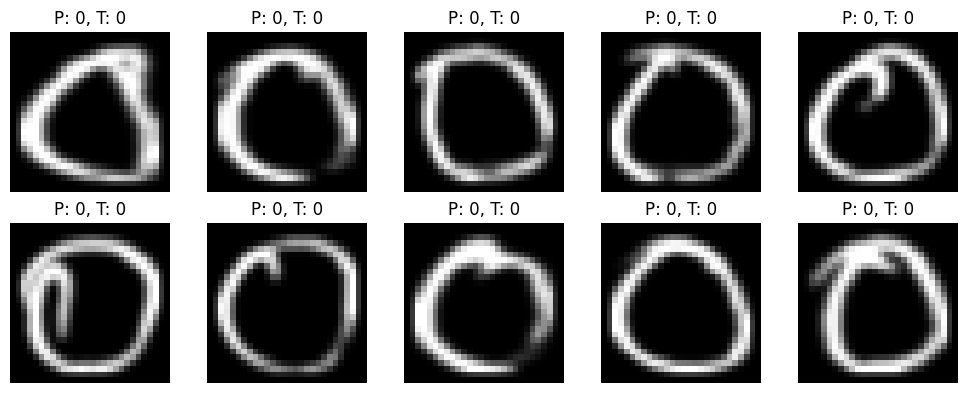

In [39]:
# Show some predictions
import numpy as np
true_labels = np.argmax(y_test, axis=1)

plt.figure(figsize=(10, 4))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_test[i].reshape(28, 28), cmap='gray')
    plt.title(f"P: {predicted_labels[i]}, T: {true_labels[i]}")
    plt.axis("off")
plt.tight_layout()
plt.show()